# Exploratory Data Analysis on Retail Sales Data

## Objective 

To perform exploratory data analysis on retail sales data to understand sales trends, customer behavior, product performance, and other key business patterns using python.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("../Data/Raw/Retail_Sales_EDA.csv")

## Initial Data Inspection

### Data Overview

In [3]:
df.head()

,Date,Customer_Age,Age_Group,Customer_Gender,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26/11/2013,19,Youth (<25),M,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26/11/2015,19,Youth (<25),M,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23/03/2014,49,Adults (35-64),M,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23/03/2016,49,Adults (35-64),M,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15/05/2014,47,Adults (35-64),F,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [4]:
df.tail()

,Date,Customer_Age,Age_Group,Customer_Gender,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
113031,12/04/2016,41,Adults (35-64),M,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,02/04/2014,18,Youth (<25),M,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,02/04/2016,18,Youth (<25),M,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,04/03/2014,37,Adults (35-64),F,Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260
113035,04/03/2016,37,Adults (35-64),F,Clothing,Vests,"Classic Vest, L",23,24,64,655,552,1207


In [5]:
df.shape

(113036, 13)

In [6]:
df.columns

Index(['Date', 'Customer_Age', 'Age_Group', 'Customer_Gender',
       'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity',
       'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue'],
      dtype='str')

In [7]:
df.dtypes

Date                  str
Customer_Age        int64
Age_Group             str
Customer_Gender       str
Product_Category      str
Sub_Category          str
Product               str
Order_Quantity      int64
Unit_Cost           int64
Unit_Price          int64
Profit              int64
Cost                int64
Revenue             int64
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Date              113036 non-null  str  
 1   Customer_Age      113036 non-null  int64
 2   Age_Group         113036 non-null  str  
 3   Customer_Gender   113036 non-null  str  
 4   Product_Category  113036 non-null  str  
 5   Sub_Category      113036 non-null  str  
 6   Product           113036 non-null  str  
 7   Order_Quantity    113036 non-null  int64
 8   Unit_Cost         113036 non-null  int64
 9   Unit_Price        113036 non-null  int64
 10  Profit            113036 non-null  int64
 11  Cost              113036 non-null  int64
 12  Revenue           113036 non-null  int64
dtypes: int64(7), str(6)
memory usage: 11.2 MB


In [9]:
df.nunique()

Date                1884
Customer_Age          70
Age_Group              4
Customer_Gender        2
Product_Category       3
Sub_Category          17
Product              130
Order_Quantity        32
Unit_Cost             34
Unit_Price            36
Profit              1256
Cost                 360
Revenue             1876
dtype: int64

### Observation

- The dataset contains `113036` rows and `13` columns.
- It contains the information about customers, products, sales transactions, revenue, cost, and profit.
- Seven numerical columns are available for statistical and correlation analysis, while remaining columns contain date, categorical, and text-based information.

## Data Cleaning


In [10]:
df.isnull().sum()

Date                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1009)

In [12]:
df[df.duplicated(keep=False)]

,Date,Customer_Age,Age_Group,Customer_Gender,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
1020,19/12/2013,22,Youth (<25),M,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245
1021,19/12/2013,22,Youth (<25),M,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245
1090,30/09/2015,42,Adults (35-64),F,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40
1091,30/09/2015,42,Adults (35-64),F,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40
1092,24/10/2013,42,Adults (35-64),F,Accessories,Bottles and Cages,Mountain Bottle Cage,2,4,10,8,8,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
111265,27/04/2014,31,Young Adults (25-34),M,Bikes,Touring Bikes,"Touring-1000 Blue, 50",1,1482,2384,378,1482,1860
111952,20/09/2013,42,Adults (35-64),M,Bikes,Touring Bikes,"Touring-3000 Yellow, 44",1,461,742,274,461,735
111953,20/09/2013,42,Adults (35-64),M,Bikes,Touring Bikes,"Touring-3000 Yellow, 44",1,461,742,274,461,735
111954,20/09/2015,42,Adults (35-64),M,Bikes,Touring Bikes,"Touring-3000 Yellow, 44",1,461,742,274,461,735


In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape


(112027, 13)

### Observation

- The dataset contains no missing values.
- A total of `1,009` exact duplicate records where identified.
- The duplicate records were removed to maintain data integrity.
- The clean dataset contains `112,027` records for further analysis.

## Descriptive Statistics

In [16]:
df.columns

Index(['Date', 'Customer_Age', 'Age_Group', 'Customer_Gender',
       'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity',
       'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue'],
      dtype='str')

In [17]:
numerical_cols =['Customer_Age','Order_Quantity','Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']
stat_summary = df[numerical_cols].describe().T
stat_summary['Median'] = df[numerical_cols].median()
stat_summary['Mode'] = df[numerical_cols].mode().iloc[0]

stat_summary


,count,mean,std,min,25%,50%,75%,max,Median,Mode
Customer_Age,112027.0,35.919662,11.016543,17.0,28.0,35.0,43.0,87.0,35.0,31
Order_Quantity,112027.0,11.904818,9.564995,1.0,2.0,10.0,20.0,32.0,10.0,1
Unit_Cost,112027.0,267.840994,550.235647,1.0,2.0,9.0,42.0,2171.0,9.0,2
Unit_Price,112027.0,453.886795,922.780090,2.0,5.0,25.0,70.0,3578.0,25.0,5
Profit,112027.0,286.057477,454.864103,-30.0,29.0,103.0,360.0,15096.0,103.0,3
Cost,112027.0,471.140618,886.997506,1.0,28.0,112.0,442.0,42978.0,112.0,1252
Revenue,112027.0,757.198095,1312.097487,2.0,64.0,226.0,806.0,58074.0,226.0,35


## Time Series Analysis

### Monthly Sales Trend

In [18]:
df["Date"] = pd.to_datetime(df["Date"],dayfirst=True)
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["Quarter"] = df["Date"].dt.quarter

In [19]:
monthly_sales_overall = df.groupby("Month",observed=True)["Revenue"].sum().reset_index()

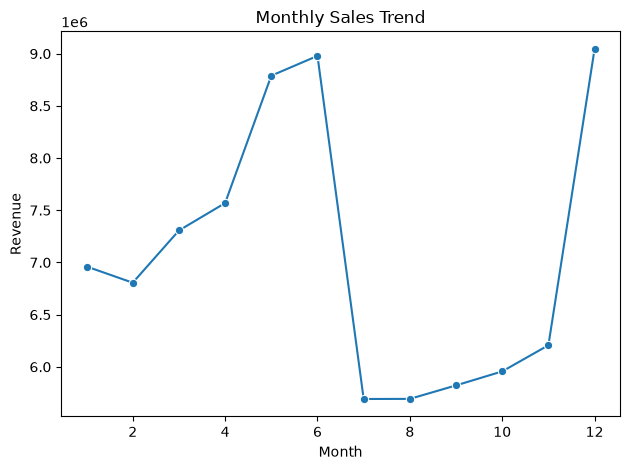

In [20]:
sns.lineplot(
    data=monthly_sales_overall,
    x = "Month",
    y = "Revenue",
    marker = 'o'
)
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()

### Observation

- Monthly revenue remains relatively stable from January to April, followed by a noticeable increase during May and June.
- Revenue reaches a high level in June and records the highest value in December.
- July and August show the lowest monthly revenue levels, after which revenue gradually increases towards December.

In [21]:
# Year wise monthly sales.

monthly_sales_year_wise = df.groupby(["Year","Month"],observed=True)["Revenue"].sum().reset_index()

Text(0.5, 1.03, 'Year wise monthly sales trend')

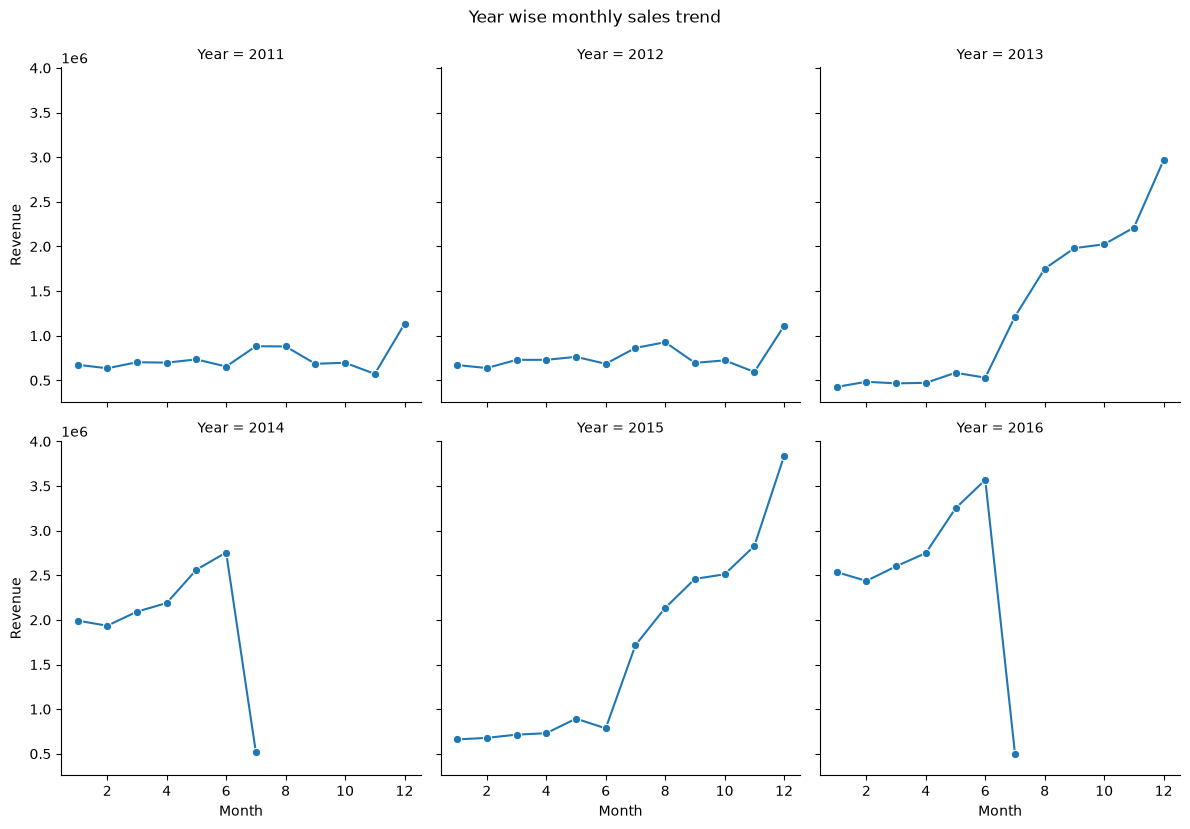

In [22]:
g = sns.relplot(
    data= monthly_sales_year_wise,
    x = "Month",
    y = "Revenue",
    col = "Year",
    col_wrap=3,
    kind = "line",
    marker = 'o',
    height=4,
)
g.set_axis_labels("Month","Revenue")
g.set_titles("Year = {col_name}")
g.fig.suptitle("Year wise monthly sales trend",y=1.03)


### Observation

- The monthly revenue pattern varies considerably across different years.
- Revenue shows strong growth during the second half of 2013 and 2015, with December recording particularly high revenue in both years.
- Revenue generally increases from January to June in 2014 and 2016, but both years have data available only up to July.
- The year 2015 shows a strong and consistent increase in revenue from July to December.

## Quarterly Sales Trend


In [23]:
quarterly_sales = df.groupby("Quarter")["Revenue"].sum().reset_index()

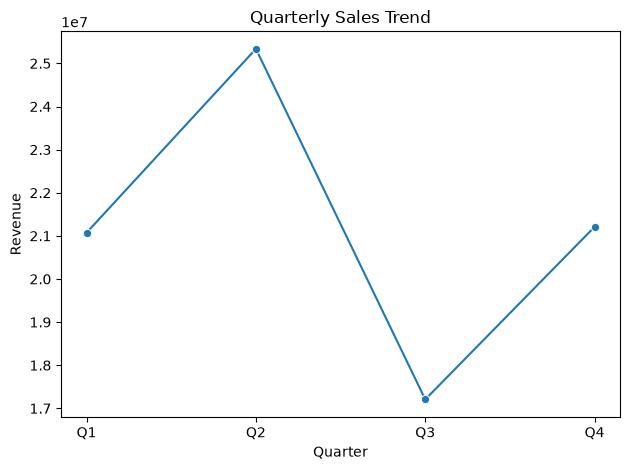

In [24]:
sns.lineplot(
    data=quarterly_sales,
    x = "Quarter",
    y = "Revenue",
    marker = 'o'
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.xticks([1,2,3,4],["Q1","Q2","Q3","Q4"])
plt.tight_layout()
plt.show()

### Observation

- Q2 records the highest overall revenue among all four quarters.
- Q3 records the lowest overall revenue, showing a significant decline compared with Q2.
- Revenue increases again in Q4, indicating a recovery after the Q3 decline.
- Q1 and Q4 show relatively similar overall revenue levels.

In [25]:
year_wise_quarterly_sales = df.groupby(["Year","Quarter"])["Revenue"].sum().reset_index()

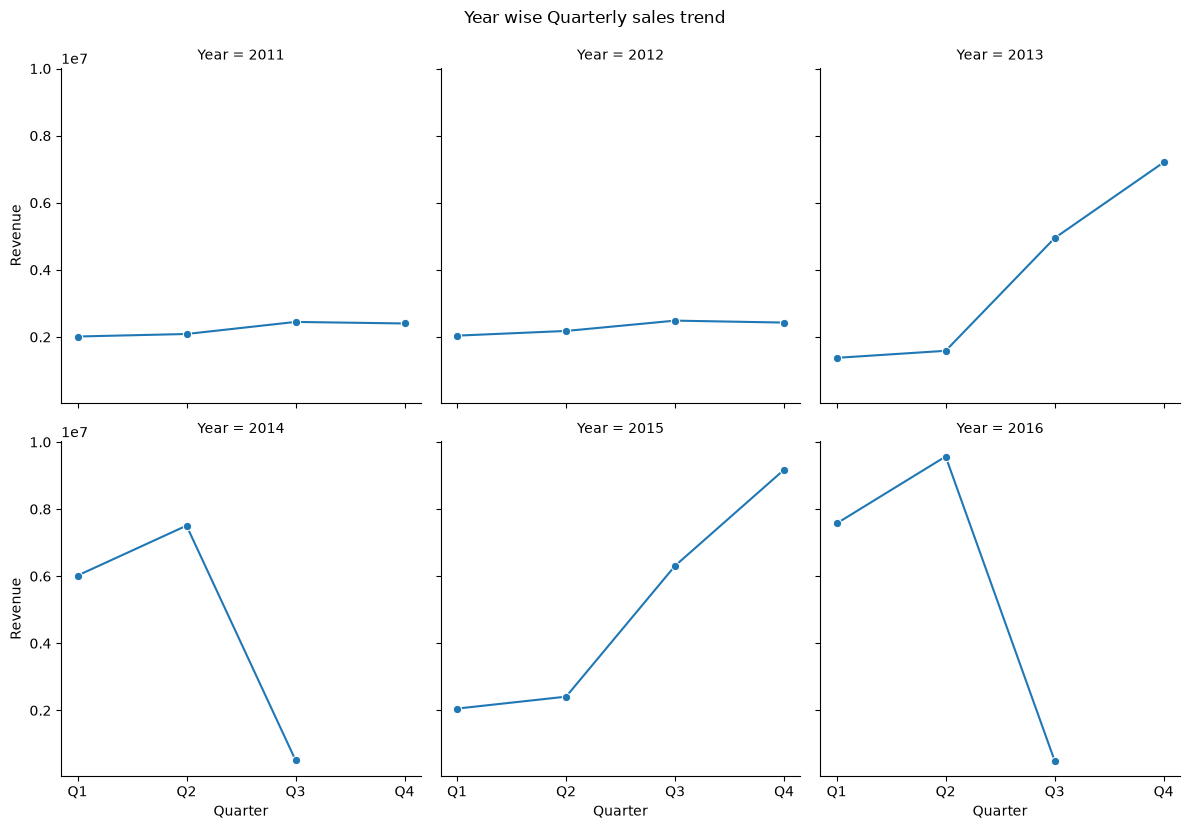

In [26]:
q =  sns.relplot(
    data= year_wise_quarterly_sales,
    x = "Quarter",
    y = "Revenue",
    col = "Year",
    col_wrap=3,
    kind = "line",
    marker = 'o',
    height=4,
)
q.set_axis_labels("Quarter","Revenue")
q.set_titles("Year = {col_name}")
q.fig.suptitle("Year wise Quarterly sales trend",y=1.03)
for ax in q.axes.flat:
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4"])

### Observation

- Quarterly revenue patterns vary across different years.
- Revenue shows a strong increase in 2013, with Q3 and Q4 recording substantially higher revenue than Q1 and Q2.
- The year 2015 shows a strong upward trend from Q1 to Q4, with Q4 recording the highest quarterly revenue.
- The years 2014 and 2016 contain data only up to Q3, so their complete quarterly performance cannot be evaluated.

## Customer Demographic Analysis

### Age Group Distribution

In [27]:
age_group_counts = df["Age_Group"].value_counts().reset_index()
age_group_counts.columns = ["Age_Group","Counts"]
age_group_counts

,Age_Group,Counts
0,Adults (35-64),55355
1,Young Adults (25-34),38295
2,Youth (<25),17658
3,Seniors (64+),719


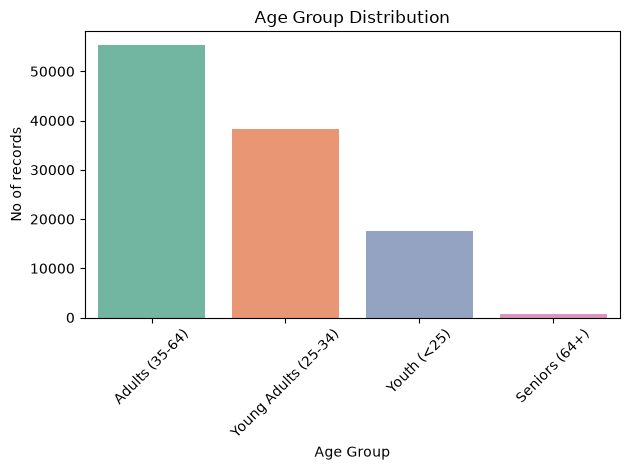

In [28]:
sns.barplot(
    data = age_group_counts,
    x = "Age_Group",
    y = "Counts",
    palette="Set2",
    hue="Age_Group"
)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("No of records")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Observation

- Adults(35-64) represents the largest age group with `55355` transaction records, suggesting that this age group contributes largest share of recorded purchases.
- Young Adults(25-34) represents the second largest age group with `38295` with transaction records, indicating a strong contribution from this age segment as well.
- Youth(<25) have comparatively fewer recorded transactions.
- Seniors(64+) have very limited representation in dataset.
- The business appears to have its strongest recorded purchashing activity among the age group (25-64).


### Gender Breakdown

In [29]:
gender_count = df["Customer_Gender"].value_counts().reset_index()
gender_count.columns = ["Customer_Gender","Count"]
gender_count

,Customer_Gender,Count
0,M,57808
1,F,54219


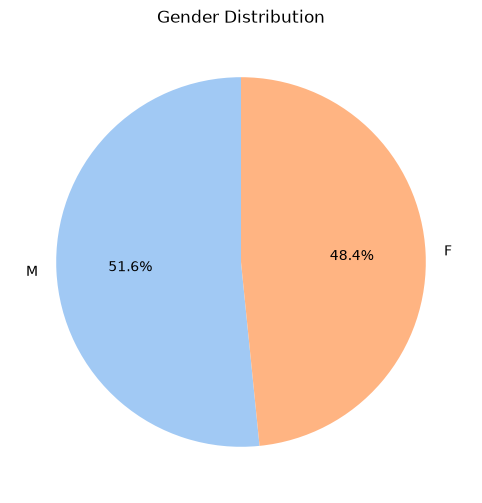

In [30]:
plt.figure(figsize=(6,6))
plt.pie(
    gender_count["Count"],
    labels= gender_count["Customer_Gender"],
    autopct= "%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.title("Gender Distribution")
plt.show()

### Observation

- Male transactions records account for **51.5%** of the total , while Female transctions records account for **48.4%**.
- The distribution is relatively balanced, with male records only slightly higher than female records.
- This indicates that the dataset represents purchasing activity from both genders fairly evenly.


## Product Analysis

### Top 10 Best-Selling Products

In [31]:
top_products = (
    df.groupby("Product")["Order_Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_products

,Product,Order_Quantity
0,Water Bottle - 30 oz.,162032
1,Patch Kit/8 Patches,155285
2,Mountain Tire Tube,100915
3,AWC Logo Cap,67316
4,"Sport-100 Helmet, Red",63652
5,Fender Set - Mountain,62118
6,"Sport-100 Helmet, Black",62072
7,Road Tire Tube,61305
8,"Sport-100 Helmet, Blue",55855
9,Touring Tire Tube,55794


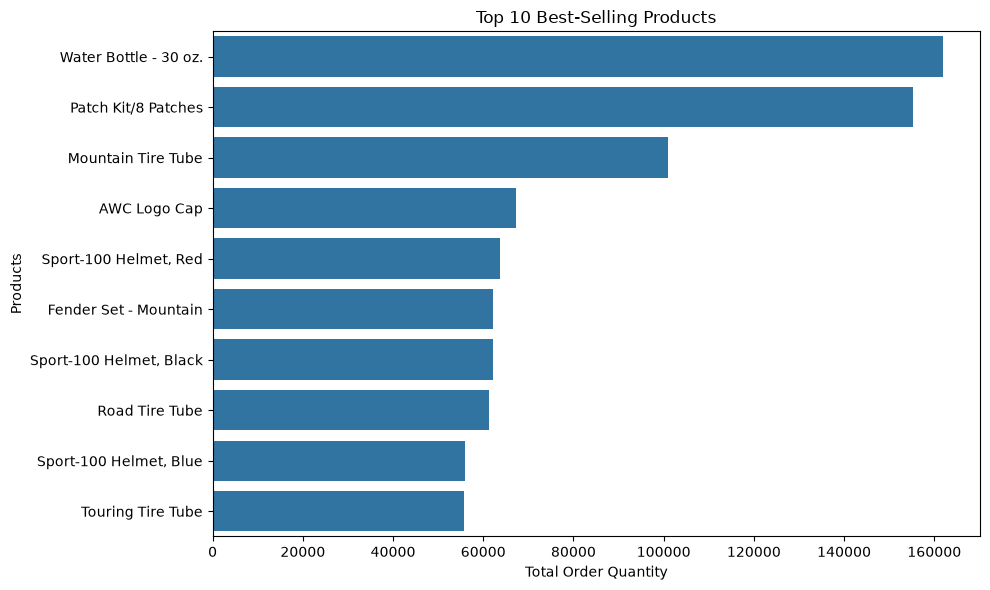

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_products,
    x = "Order_Quantity",
    y = "Product"
    
)
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Order Quantity")
plt.ylabel("Products")
plt.tight_layout()
plt.show()

### Observation 

- Water Bottle - 30 oz. is the best-selling product, with a total order quantity of 162,032 units.
- Patch Kit/8 Patches ranks second with 155,285 units, followed by Mountain Tire Tube with 100,915 units.
- The remaining products in the Top 10 have order quantities below 70,000 units, with Touring Tire Tube having the lowest quantity among the Top 10.

### Revenue By Product Categories

In [33]:
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
category_revenue

,Product_Category,Revenue
0,Bikes,61434484
1,Accessories,15022625
2,Clothing,8369522


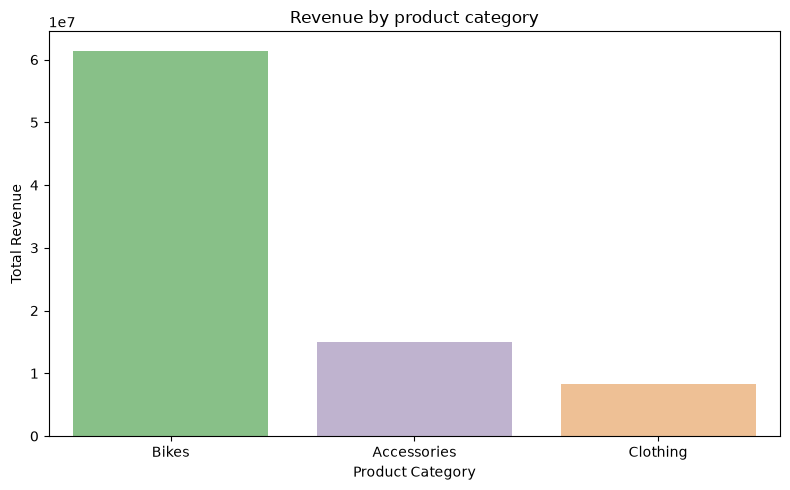

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_revenue,
    x = "Product_Category",
    y = "Revenue",
    hue = "Product_Category",
    palette = "Accent"
)

plt.title("Revenue by product category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

### Observation

- Bikes generated the highest total revenue of **61.43 million**, significantly higher than the other product categories.
- Accessories generated the second-highest revenue of approximately **15.02 million**.
- Clothing generated the lowest revenue among the three categories, with approximately **8.37 million**.

## Correlation between numerical variables

### Correlation Matrix


In [35]:
numerical_cols

['Customer_Age',
 'Order_Quantity',
 'Unit_Cost',
 'Unit_Price',
 'Profit',
 'Cost',
 'Revenue']

In [36]:
correlation = df[numerical_cols].corr()
correlation

,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
Customer_Age,1.000000,0.027362,-0.021409,-0.020309,0.004379,-0.016020,-0.009311
Order_Quantity,0.027362,1.000000,-0.516337,-0.516435,-0.238817,-0.340430,-0.312926
Unit_Cost,-0.021409,-0.516337,1.000000,0.997891,0.740617,0.829554,0.817540
Unit_Price,-0.020309,-0.516435,0.997891,1.000000,0.749445,0.825962,0.818172
Profit,0.004379,-0.238817,0.740617,0.749445,1.000000,0.902107,0.956507
Cost,-0.016020,-0.340430,0.829554,0.825962,0.902107,1.000000,0.988748
Revenue,-0.009311,-0.312926,0.817540,0.818172,0.956507,0.988748,1.000000


### Heatmap

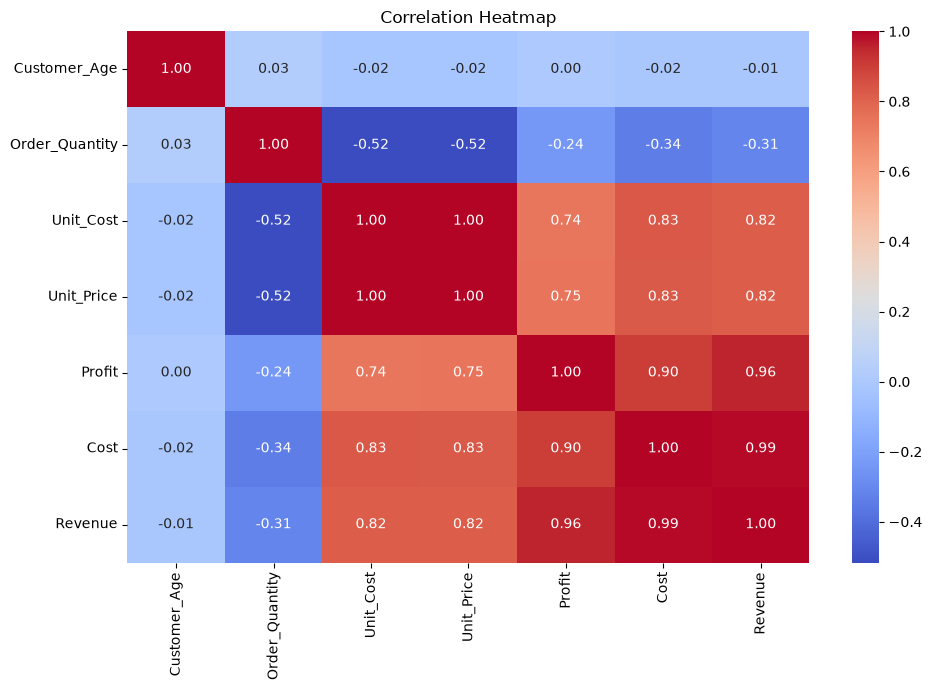

In [37]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

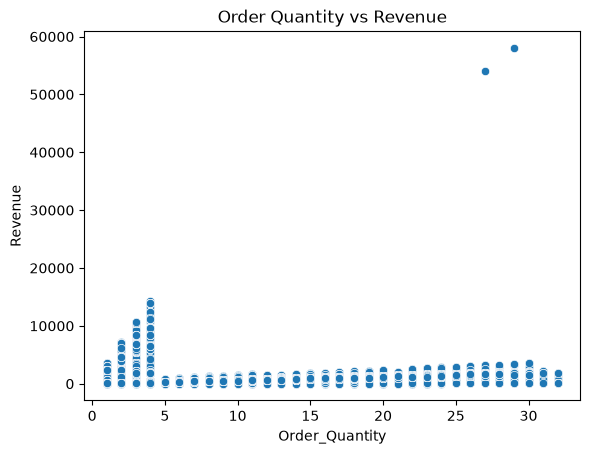

In [38]:
sns.scatterplot(
    data=df,
    x = "Order_Quantity",
    y = "Revenue"
)

plt.title("Order Quantity vs Revenue")
plt.show()

### Observation — Correlation Analysis

- **Unit Cost and Unit Price** show an extremely strong positive correlation of **0.998**, indicating that the two variables move almost perfectly together.
- **Cost and Revenue** have an extremely strong positive correlation of **0.989**, while **Profit and Revenue** also show a very strong positive correlation of **0.957**.
- **Profit and Cost** show a strong positive correlation of **0.902**, indicating that higher-cost records are generally associated with higher profit.
- **Order Quantity** has a moderate negative correlation with **Unit Cost (-0.516)** and **Unit Price (-0.516)**.
- **Order Quantity and Revenue** show a weak-to-moderate negative linear correlation of **-0.313**. The scatter plot shows a highly dispersed relationship with several outliers, so higher order quantity does not consistently correspond to higher revenue.
- **Customer Age** has correlations close to zero with the other variables, including **Revenue (-0.009)** and **Profit (0.004)**, indicating little to no linear relationship in this dataset.


## Additional Visualization


### Profit Margin by Product Categories.


In [39]:
category_revenue

,Product_Category,Revenue
0,Bikes,61434484
1,Accessories,15022625
2,Clothing,8369522


In [40]:
category_profit = (
    df.groupby("Product_Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
category_profit

,Product_Category,Profit
0,Bikes,20399726
1,Accessories,8807116
2,Clothing,2839319


In [41]:
category_profitability = category_revenue.merge(
    category_profit,
    on= "Product_Category"
)
category_profitability

,Product_Category,Revenue,Profit
0,Bikes,61434484,20399726
1,Accessories,15022625,8807116
2,Clothing,8369522,2839319


In [42]:
category_profitability["Profit_Margin"] = (
    category_profitability["Profit"] / category_profitability["Revenue"] * 100
)


In [43]:
category_profitability_sorted = category_profitability.sort_values(
    by="Profit_Margin",
    ascending=False
)
category_profitability_sorted

,Product_Category,Revenue,Profit,Profit_Margin
1,Accessories,15022625,8807116,58.625680
2,Clothing,8369522,2839319,33.924506
0,Bikes,61434484,20399726,33.205660


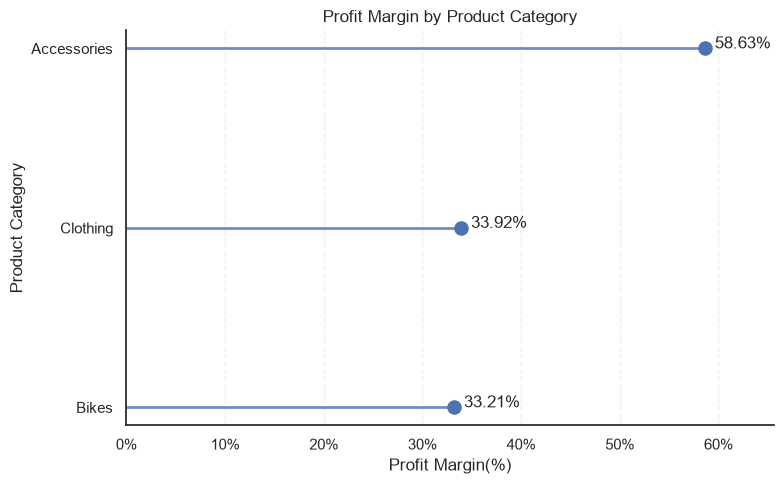

In [44]:
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="white")
plt.figure(figsize=(8,5))
sns.scatterplot(
    data= category_profitability_sorted,
    x = "Profit_Margin",
    y = "Product_Category",
    s = 130
)

plt.hlines(
    y = category_profitability_sorted["Product_Category"],
    xmin=0,
    xmax=category_profitability_sorted["Profit_Margin"],
    linewidth = 2,
    alpha = 0.8
)
plt.gca().xaxis.set_major_formatter(PercentFormatter())

for i, row in category_profitability_sorted.iterrows():
    plt.text(
        row["Profit_Margin"] + 1,
        row["Product_Category"],
        f'{row["Profit_Margin"]:.2f}%'
    )

plt.grid(
    axis = "x",
    linestyle = "--",
    alpha = 0.3
)

plt.xlim(0,category_profitability["Profit_Margin"].max() + 7)
plt.xlabel("Profit Margin(%)")
plt.ylabel("Product Category")
plt.title("Profit Margin by Product Category")
sns.despine()
plt.tight_layout()
plt.show()

### Observation

- **Accessories** has the highest profit margin at **58.63%**.
- **Clothing** has a profit margin of **33.92%**, while **Bikes** has a profit margin of **33.21%**.
- The profit margin of **Accessories** is substantially higher than that of Bikes and Clothing.

## Overall Insights


- **June and December** show relatively high monthly revenue, while **July and August** show comparatively lower revenue, indicating noticeable variation in monthly sales performance.
- **Adults (35–64)** form the largest age group with **55,355 transaction records**, followed by **Young Adults (25–34)** with **38,295 records**, showing that transaction activity is concentrated mainly among customers aged 25–64.
- **Bikes** generate the highest total revenue of approximately **61.43 million** and the highest total profit of approximately **20.40 million**, making them the strongest category in terms of absolute financial contribution.
- **Accessories** have the highest profit margin at **58.63%**, substantially higher than **Clothing (33.92%)** and **Bikes (33.21%)**. This shows that the highest-revenue category is not necessarily the highest-margin category.
- **Unit Cost and Unit Price** have an extremely strong positive correlation of **0.998**, while **Profit and Revenue** have a very strong positive correlation of **0.957**. In contrast, **Order Quantity and Revenue** have a negative correlation of **-0.313**, indicating that higher order quantities do not consistently result in higher revenue.

## Conclusion

The exploratory data analysis provides useful insights into sales trends, customer demographics, product demand, and profitability. Bikes are the strongest category in terms of total revenue and profit, while Accessories stand out because of their significantly higher profit margin. The product analysis also highlights several high-demand products that can support inventory and promotional decisions. Overall, the analysis shows that revenue performance, product demand, and profitability should be considered together when making business decisions.

### Actionable Business Recommendations

1. **Increase Accessories cross-selling:** Since Accessories have the highest profit margin of **58.63%**, promote products such as bottles, repair kits, and tubes alongside bike purchases to improve overall profitability.

2. **Focus on the Bikes category:** Bikes generate the highest revenue (**61.43 million**) and total profit (**20.40 million**). Maintaining sufficient inventory and targeted promotions for strong-performing bike products can help protect and grow this major revenue source.

3. **Use high-demand products for inventory and promotions:** Products such as **Water Bottle - 30 oz.** and **Patch Kit/8 Patches** have the highest order quantities. These products should be considered when planning inventory levels, product bundles, and promotional campaigns.